# Logistic Regression: Baseline vs Open-Question (Downscaling)

**Open question:** does downscaling the images before feature extraction affect classification performance?

**Setup:**
- **baseline LR:** features extracted at original resolution, no hair removal.
- **open_question LR:** features extracted from images resized to a maximum dimension of 256 px, no hair removal.

Hair removal is excluded from both pipelines to keep this a clean single-variable comparison (only resolution differs).

**Method:** same patient-level test split is used in both pipelines, so the predictions are paired by image and the CV folds are paired by patient subset.
- Test-set metrics (Accuracy, Precision, Recall, F1, AUC)
- ROC overlay
- Confusion matrices side by side
- Calibration plots
- Bootstrap 95% CI for AUC
- Per-fold paired comparison (Wilcoxon and t-test)

## 0. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from scipy.stats import wilcoxon, ttest_rel

FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load LR predictions and CV-fold AUCs for both pipelines

In [2]:
pred_base = pd.read_csv('../results/predictions/predictions_LR_baseline.csv')
pred_oq   = pd.read_csv('../results/predictions/predictions_LR_open_question.csv')
cv_base   = pd.read_csv('../results/predictions/cv_folds_LR_baseline.csv')
cv_oq     = pd.read_csv('../results/predictions/cv_folds_LR_open_question.csv')

print(f'baseline LR     : {len(pred_base)} test samples, {len(cv_base)} CV folds')
print(f'open_question LR: {len(pred_oq)} test samples, {len(cv_oq)} CV folds')

baseline LR     : 404 test samples, 5 CV folds
open_question LR: 404 test samples, 5 CV folds


## 2. Side-by-side test-set metrics

Same metrics as in the baseline evaluation, now compared between full-resolution and downscaled feature extraction. The `delta` column is (open_question - baseline): negative means downscaling performs worse.

In [3]:
def compute_metrics(df):
    y_true = df['label']
    y_pred = df['predicted']
    y_prob = df['probability']
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
    }

metrics_df = pd.DataFrame({
    'baseline LR':      compute_metrics(pred_base),
    'open_question LR': compute_metrics(pred_oq),
})
metrics_df['delta (oq - base)'] = metrics_df['open_question LR'] - metrics_df['baseline LR']
metrics_df.round(4)

,baseline LR,open_question LR,delta (oq - base)
Accuracy,0.6634,0.6460,-0.0173
Precision,0.7194,0.6965,-0.0229
Recall,0.6351,0.6306,-0.0045
F1,0.6746,0.6619,-0.0127
AUC,0.7548,0.7325,-0.0222


## 3. ROC overlay

Both ROC curves on one plot. Close overlap = downscaling didn't change discriminative ability; clear gap = downscaling matters.

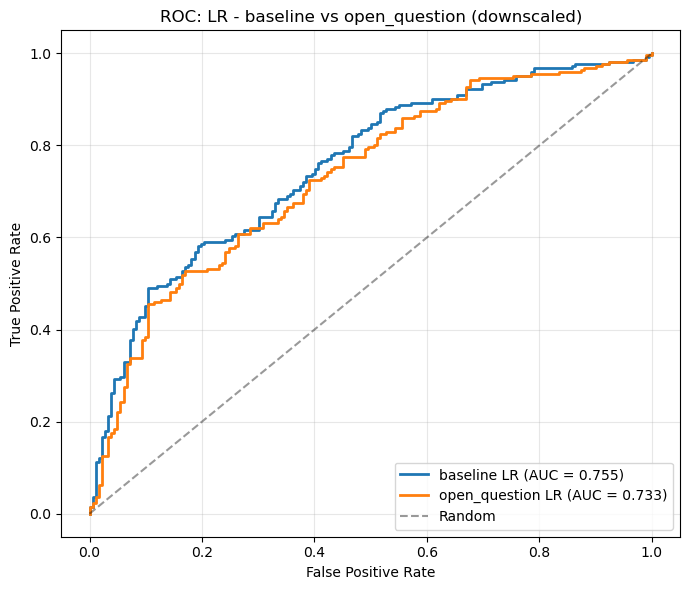

In [4]:
plt.figure(figsize=(7, 6))
for name, df, color in [('baseline LR', pred_base, 'tab:blue'),
                         ('open_question LR', pred_oq, 'tab:orange')]:
    fpr, tpr, _ = roc_curve(df['label'], df['probability'])
    auc = roc_auc_score(df['label'], df['probability'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC: LR - baseline vs open_question (downscaled)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_oq_roc.png', dpi=150)
plt.show()

## 4. Confusion matrices side by side

Does downscaling shift the balance of false positives vs false negatives?

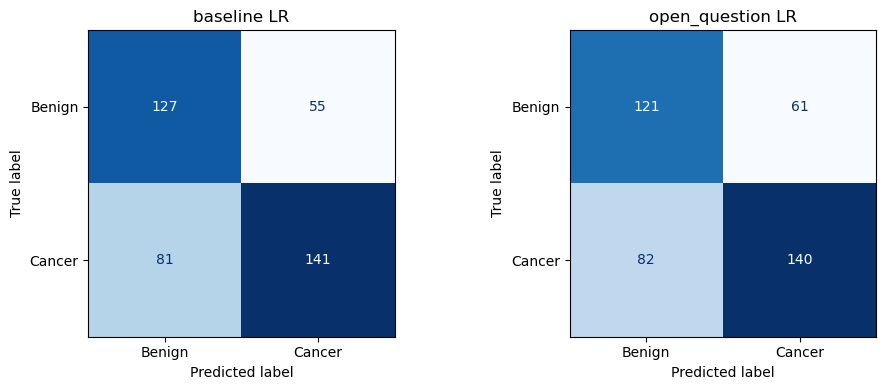

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, df) in zip(axes, [('baseline LR', pred_base), ('open_question LR', pred_oq)]):
    cm = confusion_matrix(df['label'], df['predicted'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Cancer'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_oq_cm.png', dpi=150)
plt.show()

## 5. Calibration overlay

Are the predicted probabilities still meaningful at lower image resolution?

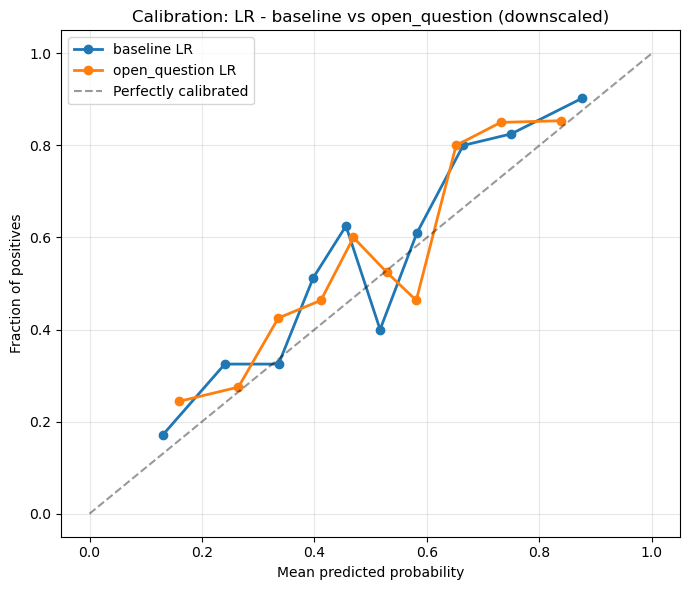

In [6]:
plt.figure(figsize=(7, 6))
for name, df, color in [('baseline LR', pred_base, 'tab:blue'),
                         ('open_question LR', pred_oq, 'tab:orange')]:
    frac_pos, mean_pred = calibration_curve(df['label'], df['probability'], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', color=color, lw=2, label=name)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration: LR - baseline vs open_question (downscaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_oq_cal.png', dpi=150)
plt.show()

## 6. Bootstrap 95% confidence intervals for AUC

Overlapping CIs mean we cannot statistically distinguish the two pipelines on the held-out test set.

In [7]:
def bootstrap_auc_ci(df, n_iter=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = df['label'].values
    y_prob = df['probability'].values
    n = len(df)
    aucs = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

base_mean, base_lo, base_hi = bootstrap_auc_ci(pred_base)
oq_mean,   oq_lo,   oq_hi   = bootstrap_auc_ci(pred_oq)

ci_df = pd.DataFrame({
    'AUC (mean)': [base_mean, oq_mean],
    'CI lower':   [base_lo, oq_lo],
    'CI upper':   [base_hi, oq_hi],
    'CI width':   [base_hi - base_lo, oq_hi - oq_lo],
}, index=['baseline LR', 'open_question LR'])
ci_df.round(4)

,AUC (mean),CI lower,CI upper,CI width
baseline LR,0.7545,0.7063,0.7975,0.0912
open_question LR,0.7322,0.6828,0.7797,0.0969


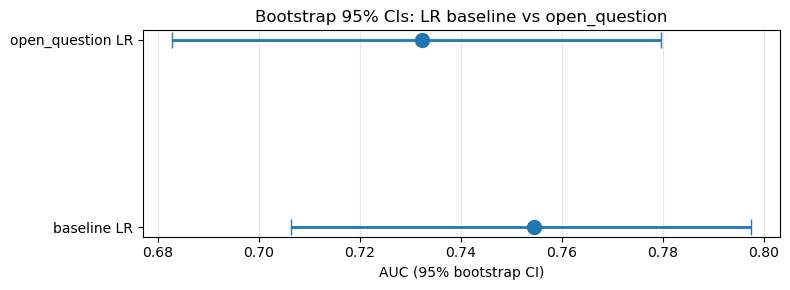

In [8]:
# Visualise CIs as error bars
fig, ax = plt.subplots(figsize=(8, 3))
y_pos = np.arange(len(ci_df))
ax.errorbar(
    ci_df['AUC (mean)'], y_pos,
    xerr=[ci_df['AUC (mean)'] - ci_df['CI lower'],
          ci_df['CI upper'] - ci_df['AUC (mean)']],
    fmt='o', capsize=6, markersize=10, lw=2,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df.index)
ax.set_xlabel('AUC (95% bootstrap CI)')
ax.set_title('Bootstrap 95% CIs: LR baseline vs open_question')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_oq_ci.png', dpi=150)
plt.show()

## 7. Per-fold paired comparison + statistical test

Five CV folds use the same patient subsets in both pipelines, so the comparison is paired. We run paired Wilcoxon + paired t-test on the per-fold differences.

**No Bonferroni correction needed** -- only one comparison.

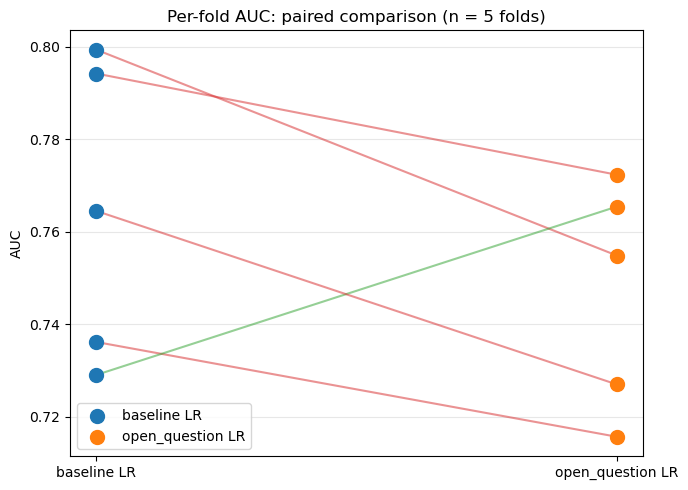

In [9]:
base_aucs = cv_base['auc'].values
oq_aucs   = cv_oq['auc'].values
diff      = oq_aucs - base_aucs

# Paired dot plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter([0]*len(base_aucs), base_aucs, color='tab:blue',   s=100, zorder=3, label='baseline LR')
ax.scatter([1]*len(oq_aucs),   oq_aucs,   color='tab:orange', s=100, zorder=3, label='open_question LR')
for i in range(len(base_aucs)):
    col = 'tab:red' if oq_aucs[i] < base_aucs[i] else 'tab:green'
    ax.plot([0, 1], [base_aucs[i], oq_aucs[i]], color=col, alpha=0.5, lw=1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['baseline LR', 'open_question LR'])
ax.set_ylabel('AUC')
ax.set_title(f'Per-fold AUC: paired comparison (n = {len(base_aucs)} folds)')
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/lr_baseline_vs_oq_paired.png', dpi=150)
plt.show()

In [10]:
# Paired statistical tests
try:
    _, w_p = wilcoxon(diff)
except ValueError:
    w_p = np.nan
_, t_p = ttest_rel(oq_aucs, base_aucs)

print(f'baseline LR per-fold AUC:      {[round(a, 4) for a in base_aucs]}  (mean = {base_aucs.mean():.4f})')
print(f'open_question LR per-fold AUC: {[round(a, 4) for a in oq_aucs]}  (mean = {oq_aucs.mean():.4f})')
print(f'Per-fold diffs (oq - base):    {[round(d, 4) for d in diff]}')
print(f'Mean diff (oq - base):         {diff.mean():+.4f}')
print()
print(f'Paired Wilcoxon p:             {w_p:.4f}')
print(f'Paired t-test p:               {t_p:.4f}')
print()
print('Interpretation:')
print('- With n=5 folds, Wilcoxon cannot reach p < 0.05 (minimum p = 0.0625).')
print('- The paired t-test is the more sensitive test here.')
print('- No Bonferroni correction: only one comparison.')

baseline LR per-fold AUC:      [np.float64(0.7994), np.float64(0.7943), np.float64(0.7362), np.float64(0.7291), np.float64(0.7645)]  (mean = 0.7647)
open_question LR per-fold AUC: [np.float64(0.7549), np.float64(0.7724), np.float64(0.7157), np.float64(0.7655), np.float64(0.727)]  (mean = 0.7471)
Per-fold diffs (oq - base):    [np.float64(-0.0445), np.float64(-0.0219), np.float64(-0.0205), np.float64(0.0364), np.float64(-0.0375)]
Mean diff (oq - base):         -0.0176

Paired Wilcoxon p:             0.3125
Paired t-test p:               0.2844

Interpretation:
- With n=5 folds, Wilcoxon cannot reach p < 0.05 (minimum p = 0.0625).
- The paired t-test is the more sensitive test here.
- No Bonferroni correction: only one comparison.


## 8. Conclusion (template)

Fill in the numbers from the cells above for the report. The interpretation depends on what you see:

**If AUC stays essentially the same** (delta within ~0.01-0.02, CIs overlap, paired tests not significant):
> Downscaling images to 256 px does not meaningfully affect classification performance for our hand-crafted features. The baseline (X) and downscaled (Y) versions produce overlapping bootstrap CIs and no significant paired difference (p = Z). This is a useful practical finding: features can be computed roughly N times faster on downscaled images with negligible cost to accuracy, making the pipeline more suitable for deployment on lower-quality smartphone photographs.

**If AUC drops noticeably:**
> Downscaling to 256 px reduces classification AUC (baseline = X, downscaled = Y, paired t-test p = Z), suggesting that high-resolution detail contributes useful signal to our colour and shape features. Practically, this implies that input image resolution is a real factor in lesion classification with hand-crafted features and that user-acquired low-resolution photographs may underperform.

**If AUC actually improves:**
> Counterintuitively, downscaling slightly improved AUC (baseline = X, downscaled = Y, p = Z). One possible explanation is that pixel-level noise (sensor noise, fine texture variation) is averaged out by the resize step, making the colour-statistics features more robust to image-acquisition artefacts. This would mean downscaling acts as a mild regulariser on the feature pipeline.